## COMP-6831: Applied Machine Learning  | Final Project: IEEE-CIS Fraud Detection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/drive/MyDrive/ieee-fraud-detection.zip" -d "/content/ieee/"


Mounted at /content/drive
Archive:  /content/drive/MyDrive/ieee-fraud-detection.zip
  inflating: /content/ieee/sample_submission.csv  
  inflating: /content/ieee/test_identity.csv  
  inflating: /content/ieee/test_transaction.csv  
  inflating: /content/ieee/train_identity.csv  
  inflating: /content/ieee/train_transaction.csv  


In [ ]:
base_path = "/content/ieee/"

transaction_train = pd.read_csv(base_path + "train_transaction.csv")
identity_train = pd.read_csv(base_path + "train_identity.csv")

print("Transaction shape:", transaction_train.shape)
print("Identity shape:", identity_train.shape)


Transaction shape: (590540, 394)
Identity shape: (144233, 41)


## Data Exploration & EDA

In [ ]:
#Converting object to category before merging to save on memory
for df in [transaction_train, identity_train]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype("category")

In [ ]:
train = transaction_train.merge(identity_train, how="left", on="TransactionID")

del transaction_train, identity_train
gc.collect()

print("Merged train shape:", train.shape)

Merged train shape: (590540, 434)


In [ ]:
def reduce_memory(df):
    for col in df.columns:
        col_type = df[col].dtype

        if col_type == "float64":
            df[col] = df[col].astype("float32")
        elif col_type == "int64":
            df[col] = df[col].astype("int32")

    return df

train = reduce_memory(train)
gc.collect()

0

In [ ]:
#DONT RUN UNLESS NECESSARY!!!!
train = train.sample(frac=0.70, random_state=42).reset_index(drop=True)
gc.collect()

train.shape

(413378, 434)

In [ ]:
# Displaying first 5 rows
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
# Data types
train.dtypes.value_counts()


,count
float64,399
object,31
int64,4


In [ ]:
# Missing values summary on train data
missing = train.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(train) * 100)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_summary.head(20)

,Missing Count,Missing %
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [ ]:
# Target distribution
fraud_counts = train['isFraud'].value_counts()
fraud_percent = train['isFraud'].value_counts(normalize=True) * 100

print("Counts:\n", fraud_counts)
print("\nPercentage:\n", fraud_percent)


Counts:
 isFraud
0    569877
1     20663
Name: count, dtype: int64

Percentage:
 isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


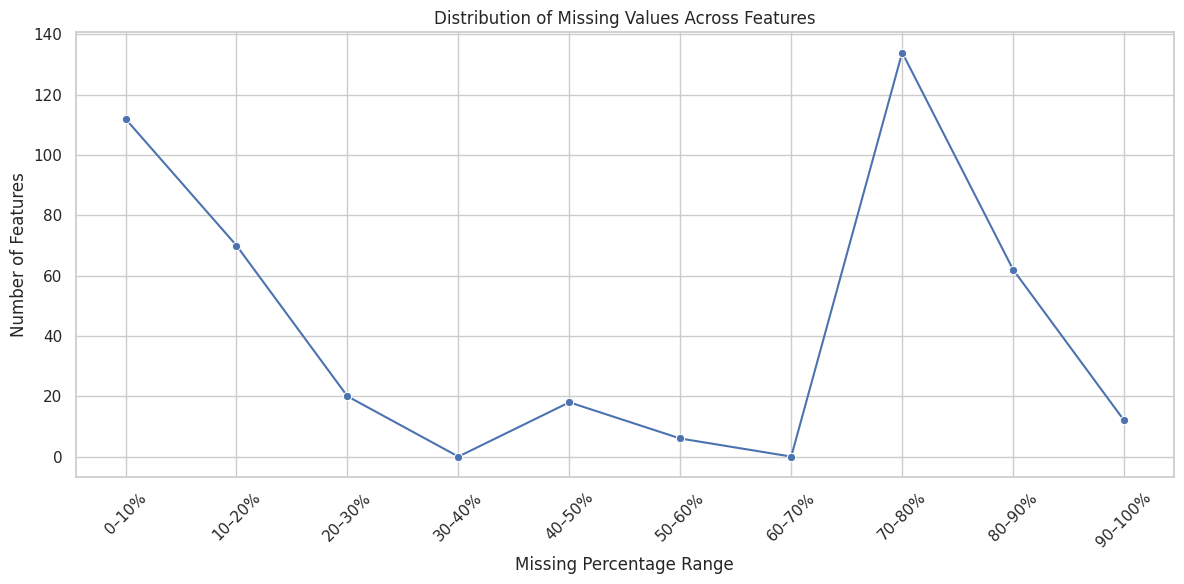

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
missing_percent = train.isna().sum() / len(train) * 100

bins = np.arange(0, 110, 10)
labels = [f"{bins[i]}–{bins[i+1]}%" for i in range(len(bins)-1)]

missing_binned = pd.cut(missing_percent, bins=bins, labels=labels, include_lowest=True)

# Counting features in each bin
bin_counts = missing_binned.value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=bin_counts.index, y=bin_counts.values, marker="o")

plt.xticks(rotation=45)
plt.xlabel("Missing Percentage Range")
plt.ylabel("Number of Features")
plt.title("Distribution of Missing Values Across Features")
plt.grid(True)
plt.tight_layout()
plt.savefig("missing_distribution_lineplot.png", dpi=300)
plt.show()

In [ ]:
# Counting features per bin
missing_table = missing_binned.value_counts().sort_index()

# Converting to DataFrame to display as table
missing_table_df = missing_table.reset_index()
missing_table_df.columns = ["Missing % Range", "Feature Count"]

missing_table_df

,Missing % Range,Feature Count
0,0–10%,112
1,10–20%,70
2,20–30%,20
3,30–40%,0
4,40–50%,18
5,50–60%,6
6,60–70%,0
7,70–80%,134
8,80–90%,62
9,90–100%,12


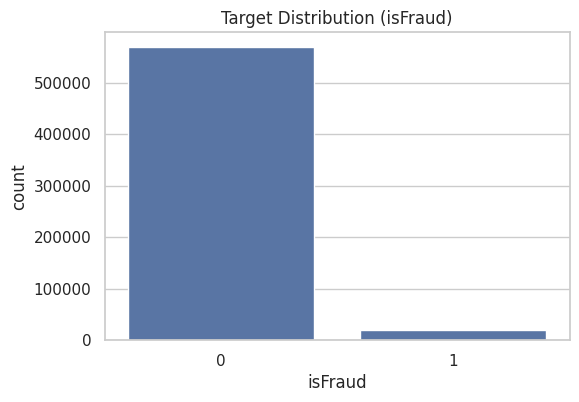

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=train, x='isFraud')
plt.title("Target Distribution (isFraud)")
plt.show()


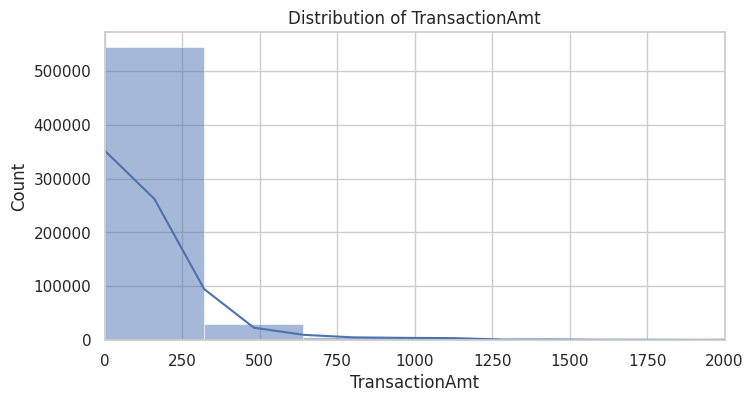

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(train['TransactionAmt'], bins=100, kde=True)
plt.title("Distribution of TransactionAmt")
plt.xlim(0, 2000)
plt.show()

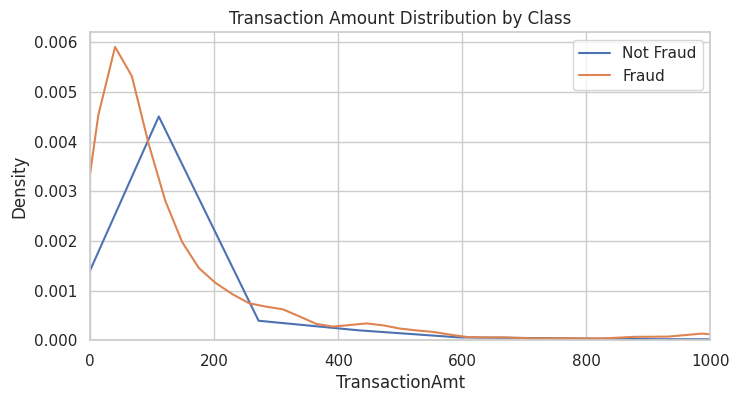

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(train.loc[train['isFraud'] == 0, 'TransactionAmt'], label='Not Fraud')
sns.kdeplot(train.loc[train['isFraud'] == 1, 'TransactionAmt'], label='Fraud')
plt.legend()
plt.title("Transaction Amount Distribution by Class")
plt.xlim(0, 1000)
plt.show()

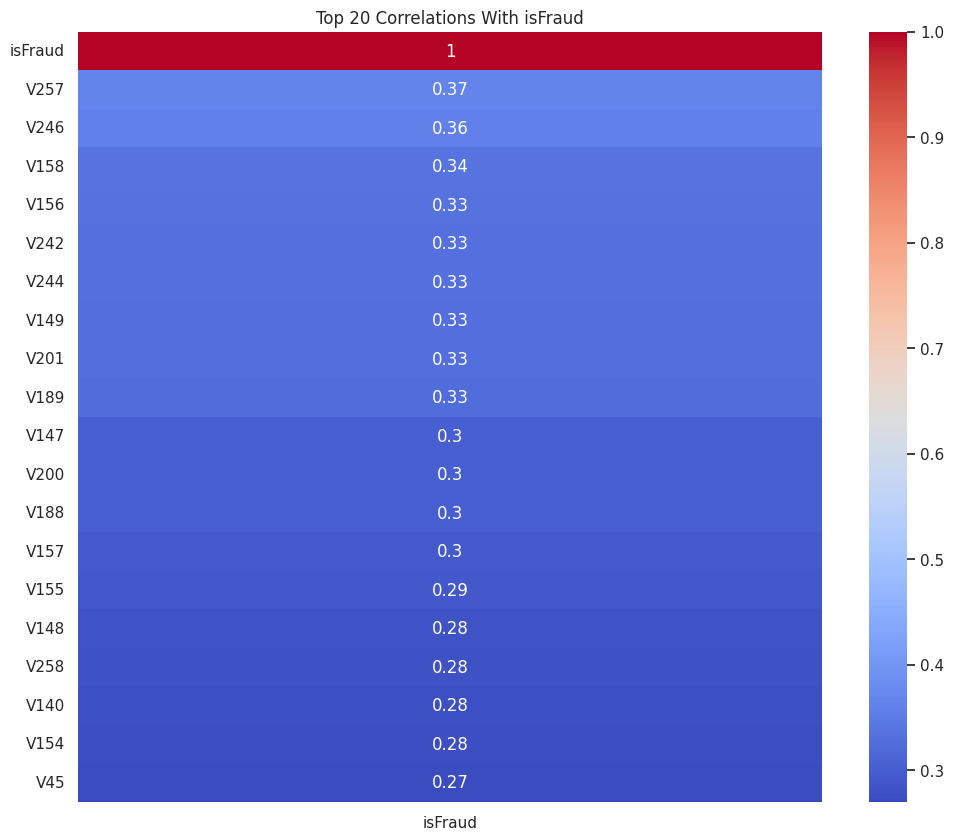

In [ ]:
#Randomy picking 2K samples for correlation
sample = train.sample(20000, random_state=42)

corr = sample.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr[['isFraud']].sort_values(by='isFraud', ascending=False).head(20),
            annot=True, cmap='coolwarm')
plt.title("Top 20 Correlations With isFraud")
plt.show()


In [ ]:
train['TransactionAmt'].describe(percentiles=[0.99, 0.999])

,TransactionAmt
count,590540.000000
mean,135.027176
std,239.162522
min,0.251000
50%,68.769000
99%,1104.000000
99.9%,2769.807320
max,31937.391000


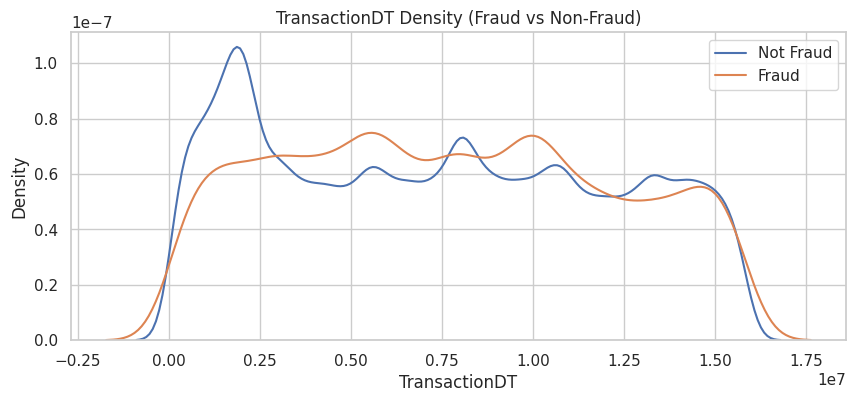

In [ ]:
plt.figure(figsize=(10,4))
sns.kdeplot(train.loc[train.isFraud==0, 'TransactionDT'], label="Not Fraud")
sns.kdeplot(train.loc[train.isFraud==1, 'TransactionDT'], label="Fraud")
plt.title("TransactionDT Density (Fraud vs Non-Fraud)")
plt.legend()
plt.show()


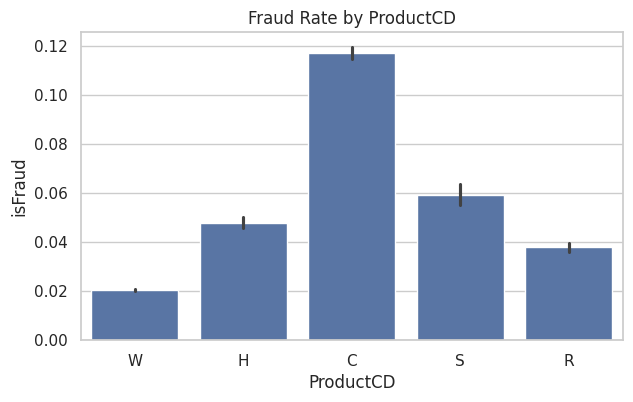

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=train,
    x='ProductCD',
    y='isFraud'
)
plt.title("Fraud Rate by ProductCD")
plt.show()


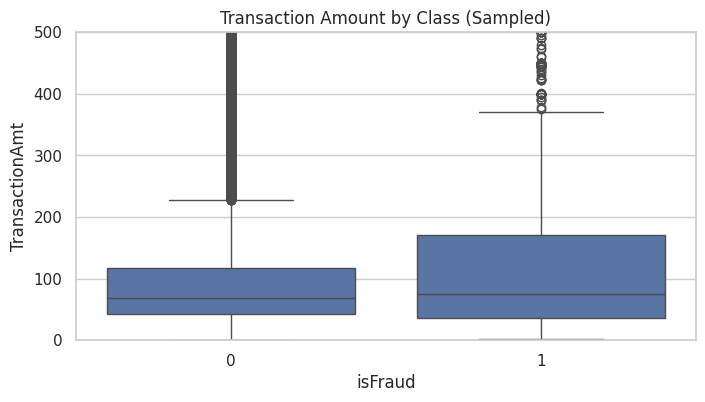

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=train.sample(50000), x='isFraud', y='TransactionAmt')
plt.title("Transaction Amount by Class (Sampled)")
plt.ylim(0,500)
plt.show()

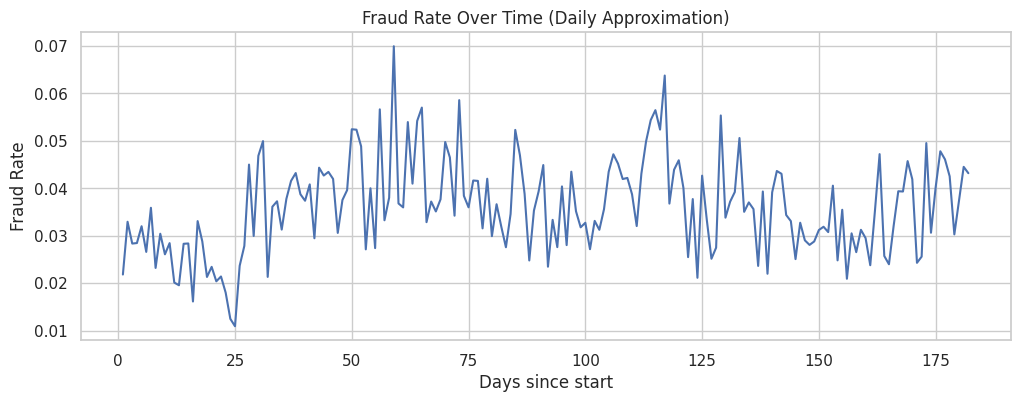

In [ ]:
plt.figure(figsize=(12,4))

# rolling-average smoothing
train['DT_smooth'] = train['TransactionDT'] // (60*60*24)

daily_fraud = train.groupby('DT_smooth')['isFraud'].mean()

plt.plot(daily_fraud.index, daily_fraud.values)
plt.title("Fraud Rate Over Time (Daily Approximation)")
plt.xlabel("Days since start")
plt.ylabel("Fraud Rate")
plt.show()

## Data Preprocessing & Cleaning

In [ ]:
missing = train.isna().mean() * 100
high_missing_cols = missing[missing > 90].index.tolist()

print("Dropping", len(high_missing_cols), "columns with >90% missing.")

train = train.drop(columns=high_missing_cols)
gc.collect()

Dropping 12 columns with >90% missing.


0

In [ ]:
y = train["isFraud"]
X = train.drop("isFraud", axis=1)

numeric_cols = X.select_dtypes(include=["float32", "int32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["category"]).columns.tolist()

len(numeric_cols), len(categorical_cols)

(392, 29)

In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_val.shape

((330702, 421), (82676, 421))

In [ ]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared   = preprocessor.transform(X_val)

X_train_prepared.shape, X_val_prepared.shape


((330702, 421), (82676, 421))

In [ ]:
del X, train
gc.collect()

64

In [ ]:
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
import numpy as np
import gc


## Model 1: Support Vector Machine (SVM)

In [ ]:
from sklearn.linear_model import SGDClassifier

svm_fast = SGDClassifier(
    loss='log_loss',
    alpha=1e-5,          # Regularization
    class_weight='balanced',  # handling imbalance
    max_iter=2000,           # number of epochs
    tol=1e-4,
    random_state=42
)

svm_fast.fit(X_train_prepared, y_train)

y_pred_svm = svm_fast.predict(X_val_prepared)

In [ ]:
# -------------------------
# 2️⃣ Evaluation Metrics
# -------------------------
print("🔹 SGDClassifier SVM Performance")
print("Accuracy:", accuracy_score(y_val, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_val, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_svm))

🔹 SGDClassifier SVM Performance
Accuracy: 0.9533477833846987

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98    113975
           1       0.36      0.45      0.40      4133

    accuracy                           0.95    118108
   macro avg       0.67      0.71      0.69    118108
weighted avg       0.96      0.95      0.96    118108

Confusion Matrix:
 [[110751   3224]
 [  2286   1847]]


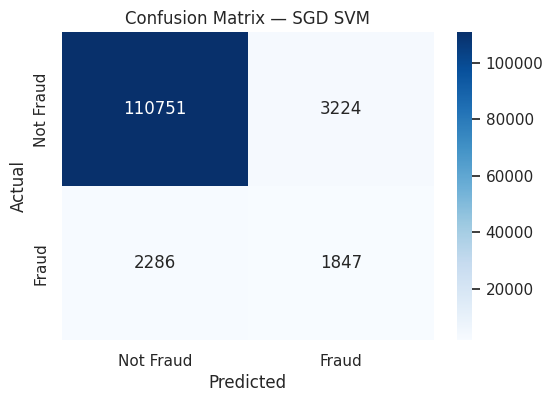

In [ ]:
# -------------------------
# 3️⃣ Confusion Matrix Heatmap
# -------------------------
cm = confusion_matrix(y_val, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title("Confusion Matrix — SGD SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier

param_grid_sgd = {
    'alpha': [1e-5, 1e-4, 1e-3],
    'loss': ['hinge', 'log_loss'],
    'learning_rate': ['optimal'],               # stable & fast
    'max_iter': [200]
}

grid_sgd = GridSearchCV(
    SGDClassifier(
        class_weight='balanced',
        tol=1e-3,
        random_state=42
    ),
    param_grid=param_grid_sgd,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_sgd.fit(X_train_prepared, y_train)

print("\n🔹 GridSearchCV Results")
print("Best Params:", grid_sgd.best_params_)
print("Best CV F1 Score:", grid_sgd.best_score_)


🔹 GridSearchCV Results
Best Params: {'alpha': 1e-05, 'learning_rate': 'optimal', 'loss': 'hinge', 'max_iter': 200}
Best CV F1 Score: 0.18475895916456256


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


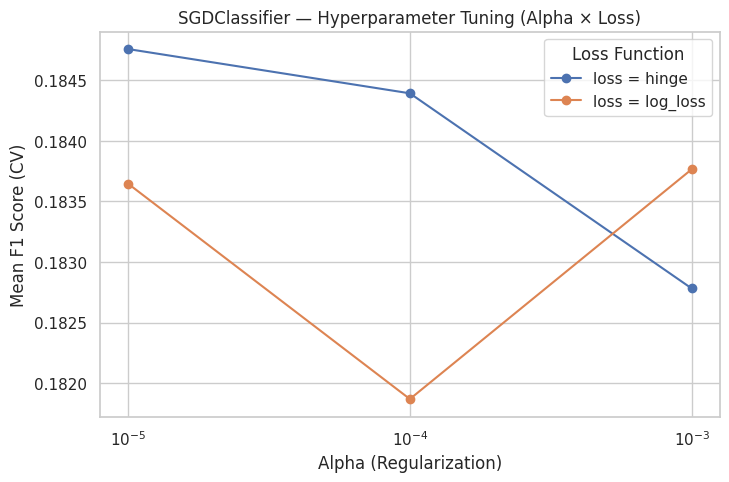

In [ ]:
results = pd.DataFrame(grid_sgd.cv_results_)

plt.figure(figsize=(8,5))

for loss in results["param_loss"].unique():
    subset = results[results["param_loss"] == loss]
    plt.plot(
        subset["param_alpha"],
        subset["mean_test_score"],
        marker='o',
        label=f"loss = {loss}"
    )

plt.xlabel("Alpha (Regularization)")
plt.ylabel("Mean F1 Score (CV)")
plt.title("SGDClassifier — Hyperparameter Tuning (Alpha × Loss)")
plt.grid(True)
plt.legend(title="Loss Function")
plt.xscale("log")  # because alpha spans orders of magnitude
plt.show()


In [ ]:
#Training with best params
best_params = grid_sgd.best_params_
print("Best Params From Grid Search:", best_params)

# Removing max_iter from best_params (so we can override it)
best_params.pop("max_iter", None)

svm_fast = SGDClassifier(
    **best_params,
    class_weight='balanced',
    max_iter=2000,
    tol=1e-4,
    random_state=42
)

svm_fast.fit(X_train_prepared, y_train)

# Predict on validation
y_pred_svm = svm_fast.predict(X_val_prepared)


Best Params From Grid Search: {'alpha': 1e-05, 'learning_rate': 'optimal', 'loss': 'hinge', 'max_iter': 200}


In [ ]:
print("\n======== FINAL METRICS: SGD SVM ========")
print("Accuracy:", accuracy_score(y_val, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_val, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_svm))



======== FINAL METRICS: SGD SVM ========
Accuracy: 0.8360822298235513

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.84      0.91    113975
           1       0.14      0.71      0.23      4133

    accuracy                           0.84    118108
   macro avg       0.56      0.77      0.57    118108
weighted avg       0.96      0.84      0.88    118108

Confusion Matrix:
 [[95826 18149]
 [ 1211  2922]]


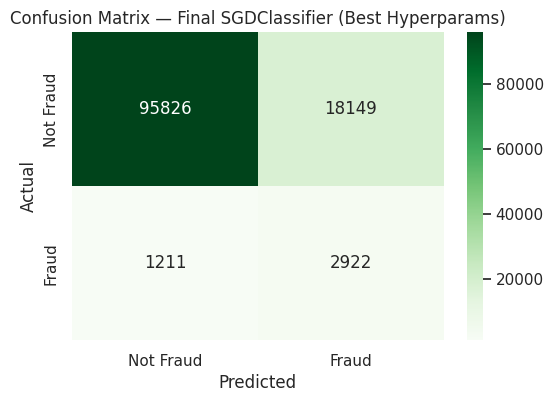

In [ ]:
# -------------------------
# 8️⃣ Confusion Matrix Heatmap — Final Model
# -------------------------
cm_final = confusion_matrix(y_val, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title("Confusion Matrix — Final SGDClassifier (Best Hyperparams)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Model 2: Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_baseline = DecisionTreeClassifier(random_state=42)

dt_baseline.fit(X_train_prepared, y_train)

y_pred_dt_base = dt_baseline.predict(X_val_prepared)

In [ ]:
print("\n===== BASELINE DECISION TREE =====")
print("Accuracy:", accuracy_score(y_val, y_pred_dt_base))
print("\nClassification Report:\n", classification_report(y_val, y_pred_dt_base))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_dt_base))



===== BASELINE DECISION TREE =====
Accuracy: 0.969028346936702

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98    113975
           1       0.55      0.60      0.57      4133

    accuracy                           0.97    118108
   macro avg       0.77      0.79      0.78    118108
weighted avg       0.97      0.97      0.97    118108

Confusion Matrix:
 [[111978   1997]
 [  1661   2472]]


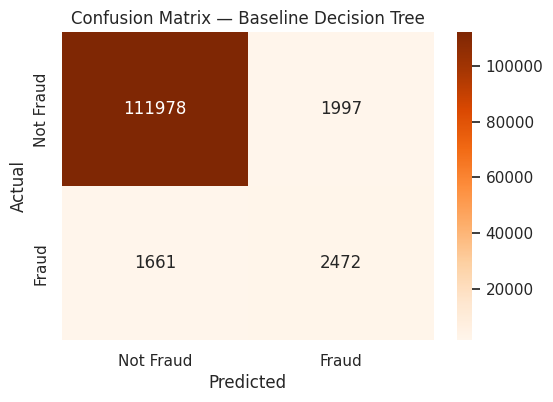

In [ ]:
cm_base_dt = confusion_matrix(y_val, y_pred_dt_base)

plt.figure(figsize=(6,4))
sns.heatmap(cm_base_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title("Confusion Matrix — Baseline Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid_dt = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_dt.fit(X_train_prepared, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, 20],
                         'min_samples_split': [5, 10]},
             scoring='f1')

In [ ]:
print("\n===== GRID SEARCH RESULTS (Decision Tree) =====")
print("Best Params:", grid_dt.best_params_)
print("Best CV F1 Score:", grid_dt.best_score_)


===== GRID SEARCH RESULTS (Decision Tree) =====
Best Params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 5}
Best CV F1 Score: 0.5310342800472303


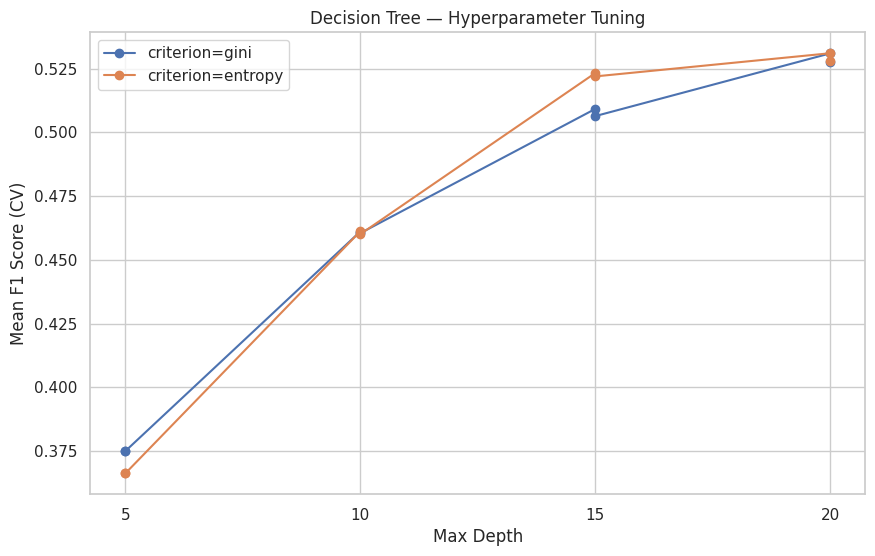

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results_dt = pd.DataFrame(grid_dt.cv_results_)

plt.figure(figsize=(10,6))

for crit in results_dt["param_criterion"].unique():
    subset = results_dt[results_dt["param_criterion"] == crit]
    plt.plot(
        subset["param_max_depth"].astype(str),
        subset["mean_test_score"],
        marker='o',
        label=f"criterion={crit}"
    )

plt.xlabel("Max Depth")
plt.ylabel("Mean F1 Score (CV)")
plt.title("Decision Tree — Hyperparameter Tuning")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
best_params_dt = grid_dt.best_params_

dt_final = DecisionTreeClassifier(
    **best_params_dt,
    random_state=42
)

dt_final.fit(X_train_prepared, y_train)

y_pred_dt = dt_final.predict(X_val_prepared)


In [ ]:
print("\n======== FINAL METRICS: DECISION TREE ========")
print("Accuracy:", accuracy_score(y_val, y_pred_dt))

print("\nClassification Report:\n", classification_report(y_val, y_pred_dt))

print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_dt))



======== FINAL METRICS: DECISION TREE ========
Accuracy: 0.9738013450094344

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     79774
           1       0.67      0.50      0.57      2902

    accuracy                           0.97     82676
   macro avg       0.83      0.75      0.78     82676
weighted avg       0.97      0.97      0.97     82676

Confusion Matrix:
 [[79050   724]
 [ 1442  1460]]


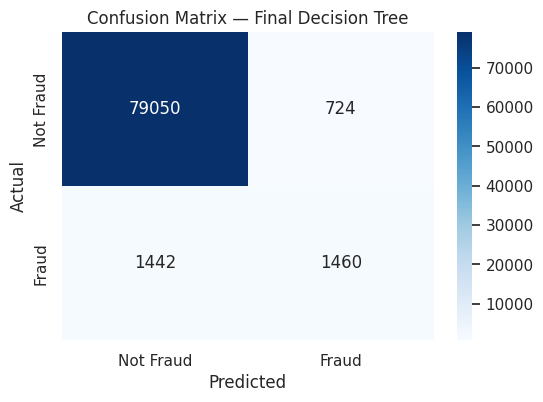

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_val, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])

plt.title("Confusion Matrix — Final Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
